In [1]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-0.2_target_data-heart_description-VANILLA_TRUE_GAT_ONLY_/42/best_20251126_143951.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: []


Model(
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (k_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (v_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (attn_proj_list): ModuleList(
        (0): Linear(in_features=2304, out_features=1, bias=True)
      )
      (edge_update): Sequential(
        (0): Linear(in_features=1536, out_features=768, bias=True)
        (1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Linear(in_features=768, out_features=768, bias=True)
      )
    )
  )
  (basis_layer_norms): ModuleList(
    (0-1): 2 x LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (coordinator): CoordinatorMLP(
    (coordinate_mlp): Sequential(
 

In [3]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=1, shuffle=False)


Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_3
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_3.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_4
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_4.pkl
Training data size: 600
Va

In [4]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





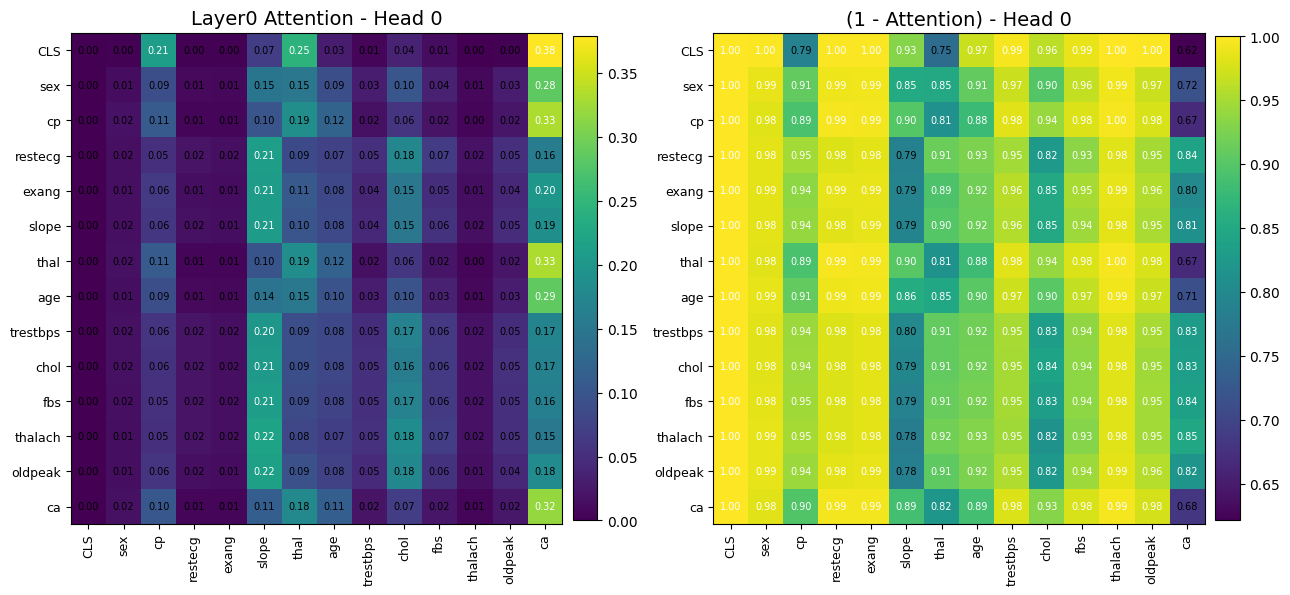

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=0.0055 | std=0.2447
            sex  | mean=0.0408 | std=2.2358
             cp  | mean=0.2841 | std=5.9956
        restecg  | mean=0.3207 | std=6.4827
          exang  | mean=0.0798 | std=2.6724
          slope  | mean=0.2397 | std=5.7122
           thal  | mean=0.2342 | std=5.3962
            age  | mean=-0.1245 | std=6.3874
       trestbps  | mean=0.0164 | std=0.2750
           chol  | mean=-0.1964 | std=4.6255
            fbs  | mean=-0.0863 | std=2.1976
        thalach  | mean=0.6268 | std=14.2191
        oldpeak  | mean=-0.2144 | std=5.2977
             ca  | mean=-0.0400 | std=2.0744

=== Global embedding statistics ===
global mean: 0.0848
global std : 5.6964


In [6]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)




========== GLOBAL CLS K-MEANS ANALYSIS ==========
>> Collecting CLS tokens from ALL sources (Limit: 10000)...
   - Processing: Heart_disease_statlog
   - Processing: Cardiovascular_Disease_Dataset
   - Processing: heart_target_3
   - Processing: heart_target_4
>> Total Collected: 3270 samples. Feature Dim: 768
>> Running K-Means (K=64)...
>> Running t-SNE (this may take a while)...


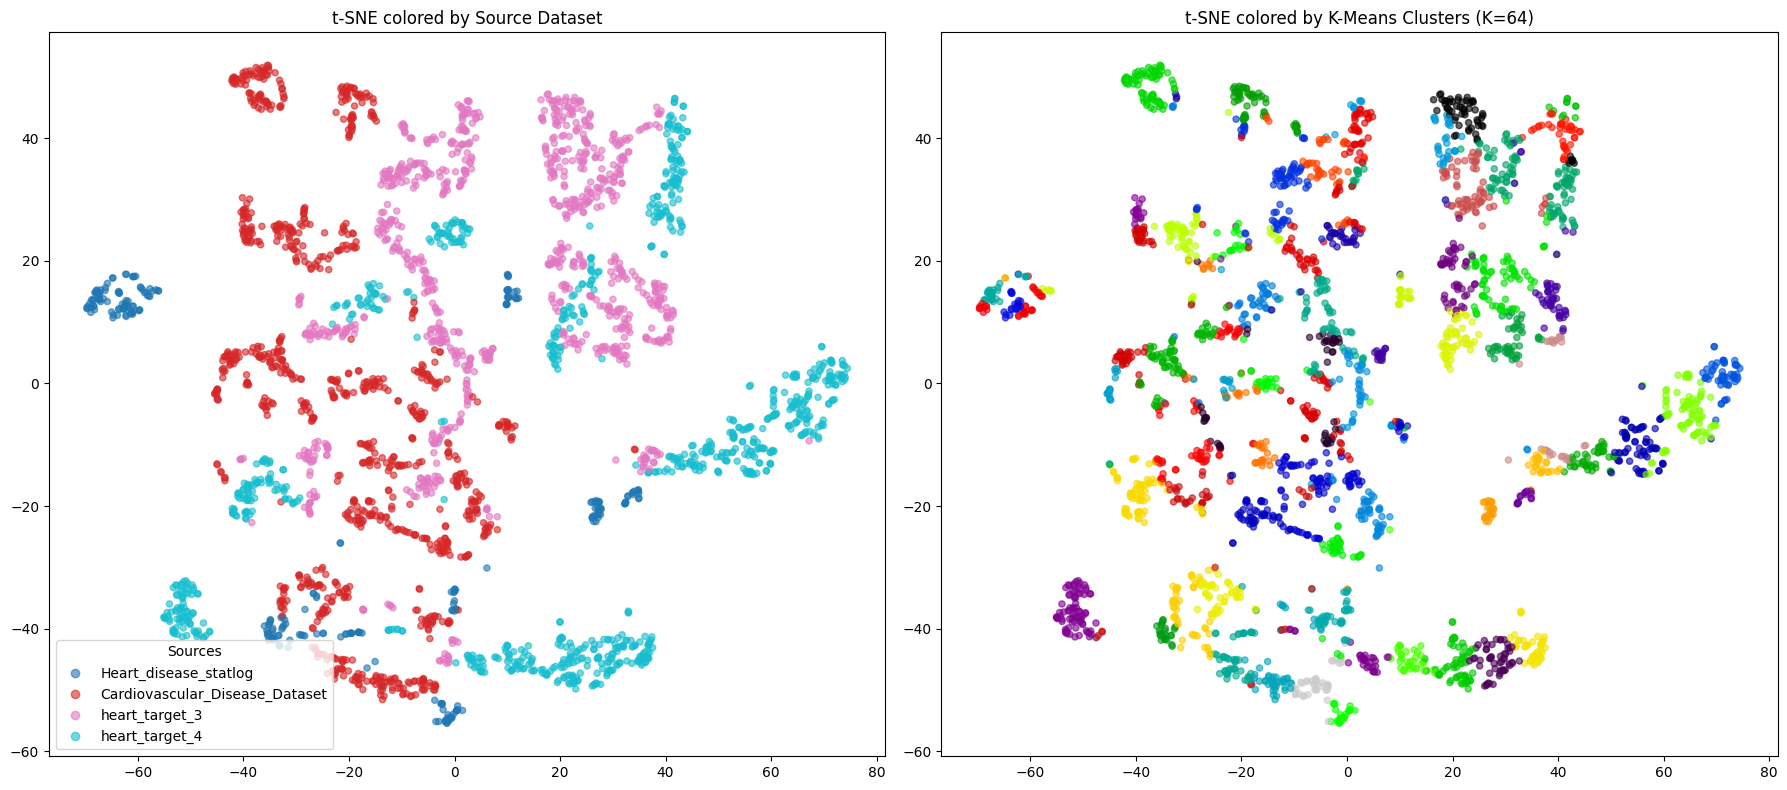

>> Analysis Complete.


In [7]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

def analyze_global_cls_clustering(model, loaders, n_clusters=64, num_samples_limit=10000):
    print(f"\n{'='*10} GLOBAL CLS K-MEANS ANALYSIS {'='*10}")
    print(f">> Collecting CLS tokens from ALL sources (Limit: {num_samples_limit})...")
    
    model.eval()
    
    all_cls = []
    all_labels = [] # Source Index (0, 1, 2...)
    source_names = []
    
    total_count = 0
    
    with torch.no_grad():
        for src_idx, (src_name, loader) in enumerate(loaders.items()):
            source_names.append(src_name)
            print(f"   - Processing: {src_name}")
            
            for batch in loader:
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # --- GAT Forward (CLS 추출) ---
                # 1. Embedding Gather
                name_embs, val_embs = [], []
                if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
                if not name_embs: continue
                name = torch.cat(name_embs, dim=1)
                val = torch.cat(val_embs, dim=1)
                
                # 2. BasisGAT Stack
                x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                for l in range(model.num_basis_layers):
                    norm_x = model.basis_layer_norms[l](x_basis)
                    basis_outputs, _ = model.basis_layers[l](name, norm_x)
                    x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
                # 3. CLS Extraction (Index 0)
                cls_token = x_basis[:, 0, :].cpu().numpy() # [B, D]
                
                all_cls.append(cls_token)
                all_labels.extend([src_idx] * cls_token.shape[0])
                
                total_count += cls_token.shape[0]
                if total_count >= num_samples_limit: break
            if total_count >= num_samples_limit: break

    # 데이터 통합
    X = np.concatenate(all_cls, axis=0)
    y_src = np.array(all_labels)
    print(f">> Total Collected: {X.shape[0]} samples. Feature Dim: {X.shape[1]}")

    # --- 1. K-Means 수행 ---
    print(f">> Running K-Means (K={n_clusters})...")
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    y_cluster = kmeans.fit_predict(X)
    
    # --- 2. t-SNE 수행 ---
    print(">> Running t-SNE (this may take a while)...")
    # 데이터가 너무 많으면 3000개만 샘플링해서 시각화
    if X.shape[0] > 3000:
        idx = np.random.choice(X.shape[0], 3000, replace=False)
        X_vis = X[idx]
        y_src_vis = y_src[idx]
        y_cluster_vis = y_cluster[idx]
    else:
        X_vis = X
        y_src_vis = y_src
        y_cluster_vis = y_cluster
        
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
    X_embedded = tsne.fit_transform(X_vis)

    # --- 3. Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Plot A: Color by Source (데이터 출처)
    scatter1 = axes[0].scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_src_vis, cmap='tab10', alpha=0.6, s=20)
    axes[0].set_title("t-SNE colored by Source Dataset")
    axes[0].legend(handles=scatter1.legend_elements()[0], labels=source_names, title="Sources")
    
    # Plot B: Color by Cluster (K-Means 결과)
    scatter2 = axes[1].scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_cluster_vis, cmap='nipy_spectral', alpha=0.6, s=20)
    axes[1].set_title(f"t-SNE colored by K-Means Clusters (K={n_clusters})")
    
    plt.tight_layout()
    plt.show()
    
    print(">> Analysis Complete.")
    return kmeans.cluster_centers_

# 실행
# model은 이미 load된 상태여야 함
centroids = analyze_global_cls_clustering(model, loaders, n_clusters=64)